# Fire & Smoke Detection
By _**George Malak Magdy**_

SRC : [Smoke-Fire-Detection-YOLO](https://www.kaggle.com/datasets/sayedgamal99/smoke-fire-detection-yolo)




# Libraries

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2


# Helper Functions

In [ ]:
def balancer(labels_path,datasetTYPE):
    label_files = glob.glob(os.path.join(labels_path, "*.txt"))
    classes = []

    for file in label_files:
        with open(file, 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                classes.append("smoke" if class_id == 0 else "fire")

    df = pd.DataFrame(classes, columns=["Class"])
    plt.figure(figsize=(8, 5))
    sns.countplot(x="Class", data=df, palette="viridis")
    plt.title(f"Class Distribution for {datasetTYPE}")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

In [ ]:
def plot_box_sizes(labels_path,datasetTYPE):
    box_sizes = []
    for file in glob.glob(os.path.join(labels_path, "*.txt")):
        with open(file, 'r') as f:
            for line in f:
                _, _, _, w, h = map(float, line.split())
                box_sizes.append(w * h)

    plt.hist(box_sizes, bins=50, color='orange')
    plt.title(f"Distribuion of Bounding Boxes {datasetTYPE}")
    plt.xlabel("Area of Bounding Box")
    plt.ylabel("Count of Bounding Boxes")
    plt.show()

In [ ]:
def show_box(image_path, label_data, is_model=False):
    img = cv2.imread(image_path)
    if img is None:
        print(f"خطأ: تعذر تحميل الصورة من {image_path}")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    lines = []

    if not is_model:
        with open(label_data, 'r') as f:
            lines = [line.split() for line in f.readlines()]
    else:
        boxes = label_data
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            lines.append([cls, x1, y1, x2, y2, conf, True])

    for line in lines:
        if len(line) == 7:
            cls, x1, y1, x2, y2, conf, _ = line
        else:
            cls = int(line[0])
            x_c, y_c, box_w, box_h = map(float, line[1:])
            x1 = int((x_c - box_w/2) * w)
            y1 = int((y_c - box_h/2) * h)
            x2 = int((x_c + box_w/2) * w)
            y2 = int((y_c + box_h/2) * h)
            conf = None

        color = (255, 0, 0) if cls == 1 else (0, 0, 255) # red for fire, blue for smoke
        cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)

        label_name = "Smoke" if cls == 0 else "Fire"
        text = f"{label_name} {conf:.2f}" if conf is not None else label_name
        cv2.putText(img, text, (int(x1), int(y1) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [ ]:
def preprocess_dataset(input_folder, output_folder, target_size=(640, 640)):
    """
    take img with their labels and preproceesing them and save them in the output folder
    """

    in_images_dir = os.path.join(input_folder, 'images')
    in_labels_dir = os.path.join(input_folder, 'labels')

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    out_images_dir = os.path.join(output_folder, 'images')
    out_labels_dir = os.path.join(output_folder, 'labels')


    os.makedirs(out_images_dir, exist_ok=True)
    os.makedirs(out_labels_dir, exist_ok=True)


    image_files = [f for f in os.listdir(in_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f" Process {len(image_files)} img...")

    for img_name in image_files:
        img_path = os.path.join(in_images_dir, img_name)

        # read img
        image = cv2.imread(img_path)
        if image is None:
            continue

        # resize for yolo 640*640
        resized_img = cv2.resize(image, target_size)

        # reduce the brithness
        hsv = cv2.cvtColor(resized_img, cv2.COLOR_BGR2HSV)
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * 0.6, 0, 255)
        processed_img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

        # save with same name
        out_img_path = os.path.join(out_images_dir, img_name)
        cv2.imwrite(out_img_path, processed_img)

        # save with label
        label_name = os.path.splitext(img_name)[0] + '.txt'
        in_label_path = os.path.join(in_labels_dir, label_name)
        out_label_path = os.path.join(out_labels_dir, label_name)
        print(f"img {img_name} Finisheed")

        if os.path.exists(in_label_path):
            with open(in_label_path, 'r') as f_in:
                label_data = f_in.read()

            with open(out_label_path, 'w') as f_out:
                f_out.write(label_data)

    print("✓ Finished !")

# Load dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sayedgamal99/smoke-fire-detection-yolo")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'smoke-fire-detection-yolo' dataset.
Path to dataset files: /kaggle/input/smoke-fire-detection-yolo


In [ ]:
con = os.listdir(path)
path = os.path.join(path, con[1])
print(path)

/kaggle/input/smoke-fire-detection-yolo/data


In [ ]:
train_data_path = os.path.join(path, 'train')
val_data_path = os.path.join(path, 'val')
test_data_path = os.path.join(path, 'test')

In [ ]:
contian_folder_path = os.listdir(train_data_path)
print(contian_folder_path)
contian_folder_path = os.listdir(val_data_path)
print(contian_folder_path)
contian_folder_path = os.listdir(test_data_path)
print(contian_folder_path)


['labels', 'images']
['labels', 'images']
['labels', 'images']


In [ ]:
print("In Train File:")
print(f"Number of Images: {len(os.listdir(os.path.join(train_data_path, 'images')))}")
print(f"Number of Labels: {len(os.listdir(os.path.join(train_data_path, 'labels')))}")
print("\nIn Validation File:")
print(f"Number of Images: {len(os.listdir(os.path.join(val_data_path, 'images')))}")
print(f"Number of Labels: {len(os.listdir(os.path.join(val_data_path, 'labels')))}")
print("\nIn Test File:")
print(f"Number of Images: {len(os.listdir(os.path.join(test_data_path, 'images')))}")
print(f"Number of Labels: {len(os.listdir(os.path.join(test_data_path, 'labels')))}")

In Train File:
Number of Images: 14122
Number of Labels: 14122

In Validation File:
Number of Images: 3099
Number of Labels: 3099

In Test File:
Number of Images: 4306
Number of Labels: 4306


# EDA

/tmp/ipykernel_3607/1676452708.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette="viridis")


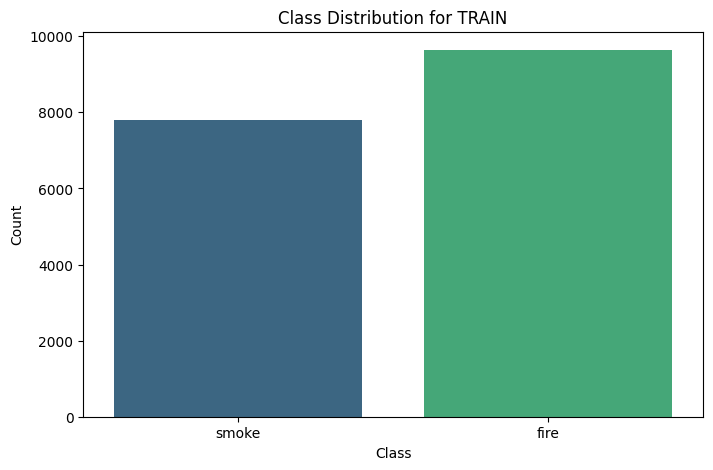

/tmp/ipykernel_3607/1676452708.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette="viridis")


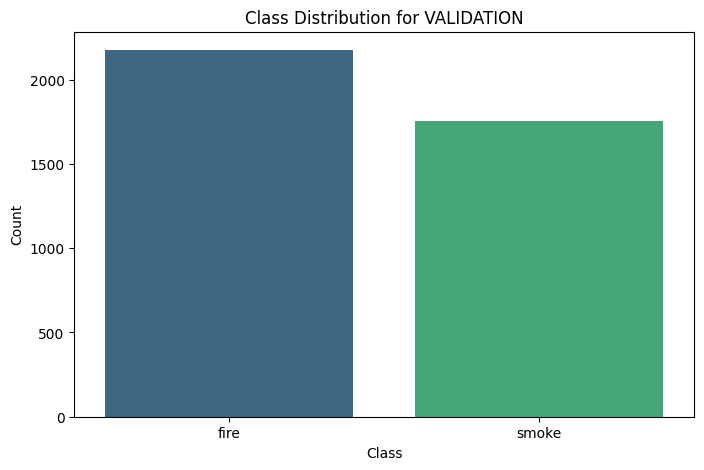

/tmp/ipykernel_3607/1676452708.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette="viridis")


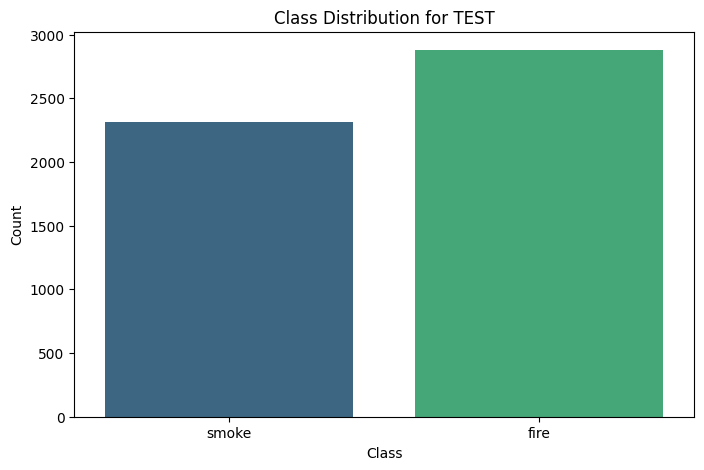

In [ ]:
lable_train = train_data_path+"/labels"
lable_val = val_data_path+"/labels"
lable_test = test_data_path+"/labels"

balancer(lable_train,"TRAIN")
balancer(lable_val,"VALIDATION")
balancer(lable_test,"TEST")

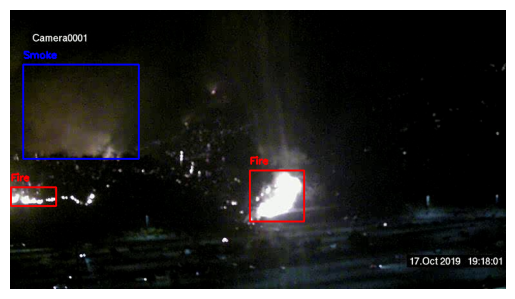

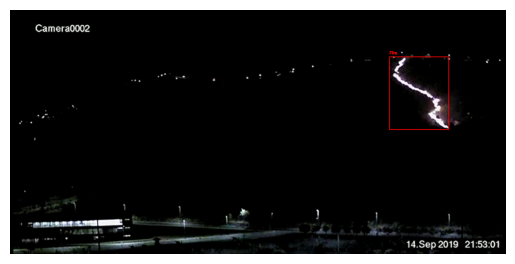

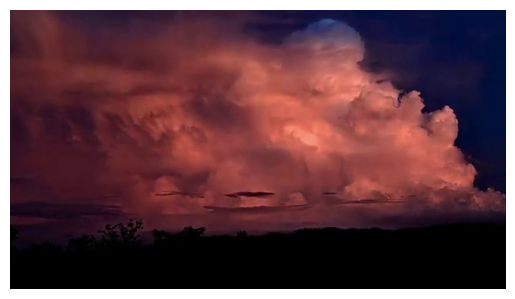

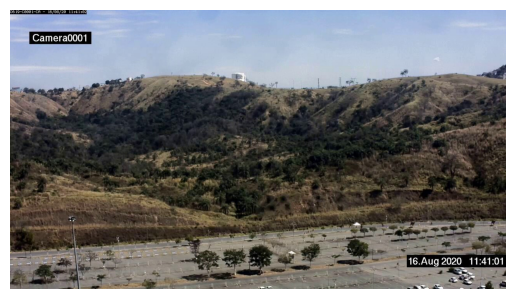

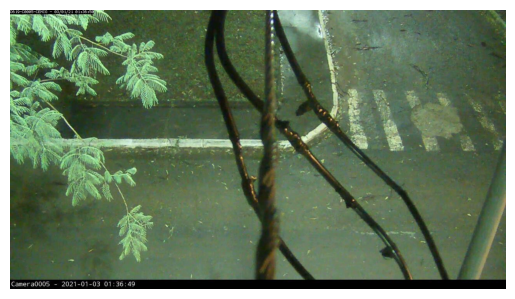

In [ ]:
import random
images_path = os.path.join(train_data_path, "images")
labels_path = lable_train
num_samples = 5

all_lab_fil = [f for f in os.listdir(labels_path) if f.endswith('.txt')]

random_lab_fil = random.sample(all_lab_fil, num_samples)

for label_file in random_lab_fil:
    file_name = os.path.splitext(label_file)[0]

    image_file = None
    for ext in ['.jpg', '.png', '.jpeg']:
        potential_path = os.path.join(images_path, file_name + ext)
        if os.path.exists(potential_path):
            image_file = potential_path
            break

    if image_file:
        label_file_path = os.path.join(labels_path, label_file)
        show_box(image_file, label_file_path,False)
    else:
        print(f"NOT FOUND BRO {label_file}")


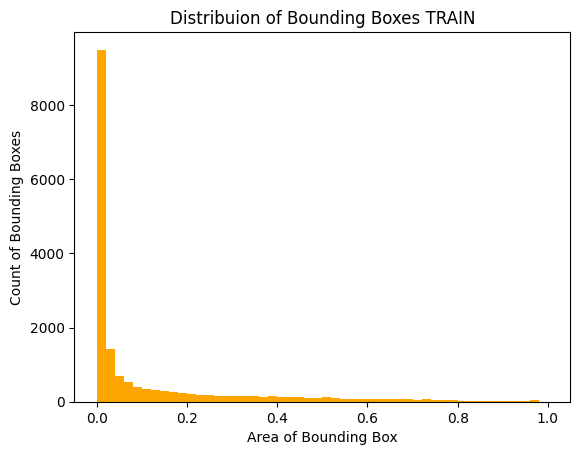

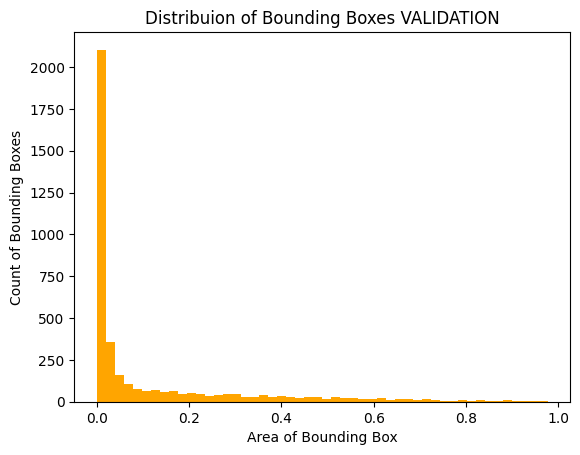

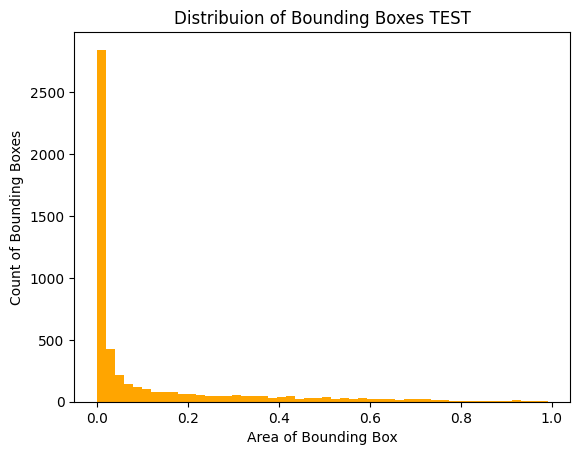

In [ ]:
plot_box_sizes(lable_train, "TRAIN")
plot_box_sizes(lable_val,"VALIDATION")
plot_box_sizes(lable_test,"TEST")

# Preprocessing

In [ ]:
train_processed_path = "ready_dataset/train/"
val_processed_path = "ready_dataset/val/"
preprocess_dataset(train_data_path, train_processed_path)
preprocess_dataset(val_data_path, val_processed_path)

Streaming output truncated to the last 5000 lines.
img PublicDataset00705.jpg Finisheed
img WEB03530.jpg Finisheed
img PublicDataset00893.jpg Finisheed
img WEB04048.jpg Finisheed
img AoF04281.jpg Finisheed
img WEB05136.jpg Finisheed
img WEB02719.jpg Finisheed
img WEB08278.jpg Finisheed
img WEB07525.jpg Finisheed
img WEB00101.jpg Finisheed
img WEB06519.jpg Finisheed
img WEB03270.jpg Finisheed
img WEB01655.jpg Finisheed
img AoF01382.jpg Finisheed
img AoF00354.jpg Finisheed
img AoF05738.jpg Finisheed
img PublicDataset00413.jpg Finisheed
img AoF00205.jpg Finisheed
img WEB00569.jpg Finisheed
img AoF00108.jpg Finisheed
img AoF06575.jpg Finisheed
img WEB00146.jpg Finisheed
img AoF04148.jpg Finisheed
img WEB08526.jpg Finisheed
img WEB01064.jpg Finisheed
img WEB06513.jpg Finisheed
img AoF02919.jpg Finisheed
img WEB08915.jpg Finisheed
img AoF06408.jpg Finisheed
img AoF04942.jpg Finisheed
img WEB03742.jpg Finisheed
img AoF01501.jpg Finisheed
img AoF00317.jpg Finisheed
img AoF00697.jpg Finisheed
i